         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


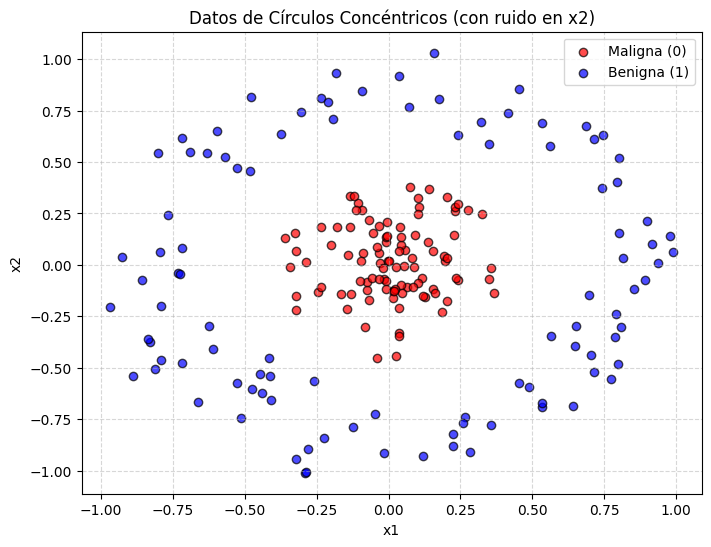

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurar semilla para reproducibilidad
np.random.seed(42)

# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2

# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)

# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)

# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])

# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido

# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})

# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())

# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')

plt.title('Datos de Círculos Concéntricos (con ruido en x2)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Clasificacion con Multilayer Perceptron

Se entrena un modelo `MLPClassifier` usando los datos concentricos generados arriba. La red usa 150 epocas (`max_iter=150`) y se evaluan varias tasas de aprendizaje para escoger la mejor con validacion cruzada.


In [2]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

# Variables predictoras y etiqueta
X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo_base = Pipeline([
    ('escalador', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        max_iter=150,
        random_state=42,
        early_stopping=False
    ))
])

learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]
param_grid = {'mlp__learning_rate_init': learning_rates}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
busqueda_lr = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

busqueda_lr.fit(X_train, y_train)
mejor_modelo = busqueda_lr.best_estimator_

print(f'Mejor learning rate: {busqueda_lr.best_params_["mlp__learning_rate_init"]}')
print(f'Mejor accuracy promedio en validacion cruzada: {busqueda_lr.best_score_:.4f}')


Mejor learning rate: 0.005
Mejor accuracy promedio en validacion cruzada: 1.0000


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


In [3]:
# Resultados de todas las tasas de aprendizaje probadas
resultados_lr = pd.DataFrame(busqueda_lr.cv_results_)[[
    'param_mlp__learning_rate_init',
    'mean_train_score',
    'std_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('rank_test_score')

resultados_lr


,param_mlp__learning_rate_init,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
3,0.0050,1.000000,0.000000,1.000000,0.000000,1
4,0.0100,1.000000,0.000000,1.000000,0.000000,1
5,0.0500,1.000000,0.000000,1.000000,0.000000,1
2,0.0010,0.916667,0.011785,0.900000,0.081650,4
1,0.0005,0.620000,0.032745,0.606667,0.071181,5
0,0.0001,0.383333,0.009129,0.380000,0.049889,6


In [4]:
# Ver todos los parametros del mejor pipeline y del MLP interno
parametros_pipeline = pd.DataFrame(
    mejor_modelo.get_params().items(),
    columns=['parametro', 'valor']
)

parametros_mlp = pd.DataFrame(
    mejor_modelo.named_steps['mlp'].get_params().items(),
    columns=['parametro_mlp', 'valor']
)

display(parametros_pipeline)
display(parametros_mlp)


,parametro,valor
0,memory,None
1,steps,"[(escalador, StandardScaler()), (mlp, MLPClass..."
2,transform_input,None
3,verbose,False
4,escalador,StandardScaler()
5,mlp,"MLPClassifier(hidden_layer_sizes=(16, 8), lear..."
6,escalador__copy,True
7,escalador__with_mean,True
8,escalador__with_std,True
9,mlp__activation,relu


,parametro_mlp,valor
0,activation,relu
1,alpha,0.0001
2,batch_size,auto
3,beta_1,0.9
4,beta_2,0.999
5,early_stopping,False
6,epsilon,0.0
7,hidden_layer_sizes,"(16, 8)"
8,learning_rate,constant
9,learning_rate_init,0.005


Accuracy en prueba: 1.0000

Reporte de clasificacion:
              precision    recall  f1-score   support

 Maligna (0)       1.00      1.00      1.00        25
 Benigna (1)       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



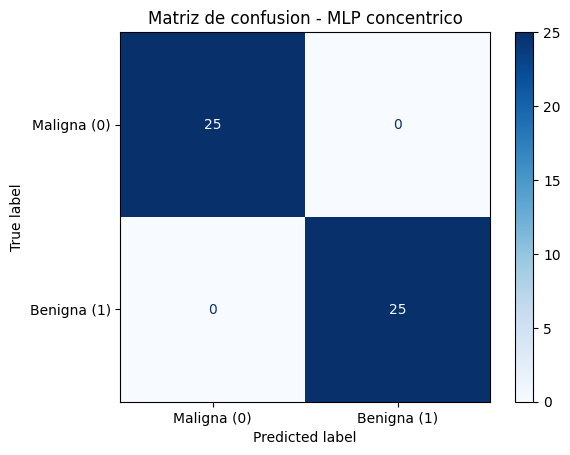

In [5]:
# Evaluacion del mejor modelo en el conjunto de prueba
y_pred = mejor_modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy en prueba: {accuracy:.4f}')
print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Maligna (0)', 'Benigna (1)']))

matriz = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=['Maligna (0)', 'Benigna (1)']
)
disp.plot(cmap='Blues')
plt.title('Matriz de confusion - MLP concentrico')
plt.grid(False)
plt.show()


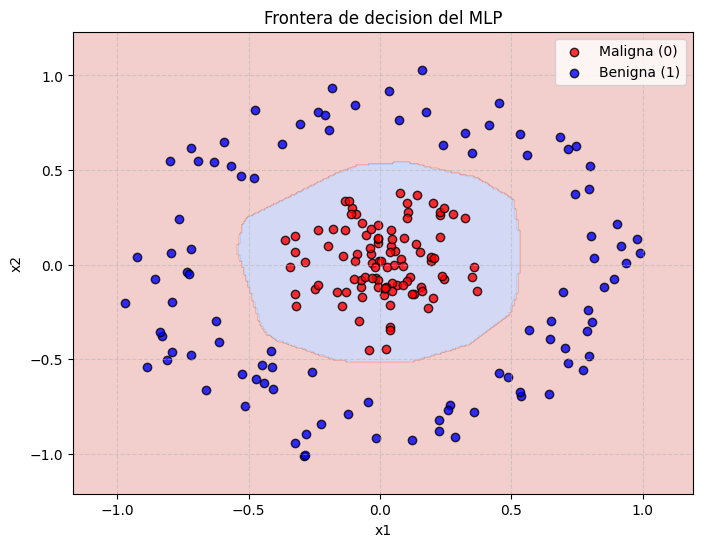

In [6]:
# Visualizar la frontera de decision aprendida
x1_min, x1_max = X['x1'].min() - 0.2, X['x1'].max() + 0.2
x2_min, x2_max = X['x2'].min() - 0.2, X['x2'].max() + 0.2
xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grilla = pd.DataFrame({'x1': xx.ravel(), 'x2': yy.ravel()})
zz = mejor_modelo.predict(grilla).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
plt.scatter(
    X[y == 0]['x1'], X[y == 0]['x2'],
    color='red', label='Maligna (0)', alpha=0.8, edgecolors='k'
)
plt.scatter(
    X[y == 1]['x1'], X[y == 1]['x2'],
    color='blue', label='Benigna (1)', alpha=0.8, edgecolors='k'
)
plt.title('Frontera de decision del MLP')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [7]:
print("Capas ocultas:", mejor_modelo.named_steps["mlp"].hidden_layer_sizes)
print("Accuracy:", accuracy)

Capas ocultas: (16, 8)
Accuracy: 1.0


In [ ]:
# Guardar el modelo entrenado con joblib
from pathlib import Path

ruta_modelo = Path('Perceptron/modelo_mlp_concentrico.joblib')
if not ruta_modelo.parent.exists():
    ruta_modelo = Path('modelo_mlp_concentrico.joblib')

joblib.dump(mejor_modelo, ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')


In [9]:
# Prediccion con un nuevo dato: x1=0.48, x2=0.48
nuevo_dato = pd.DataFrame({'x1': [-0.26], 'x2': [-0.25]})

prediccion = mejor_modelo.predict(nuevo_dato)[0]
probabilidades = mejor_modelo.predict_proba(nuevo_dato)[0]

clases = {0: 'Maligna', 1: 'Benigna'}

print(f'Dato a predecir: x1={nuevo_dato.loc[0, "x1"]}, x2={nuevo_dato.loc[0, "x2"]}')
print(f'Clase predicha: {prediccion} - {clases[prediccion]}')
print(f'Probabilidad Maligna (0): {probabilidades[0]:.4f}')
print(f'Probabilidad Benigna (1): {probabilidades[1]:.4f}')


Dato a predecir: x1=-0.26, x2=-0.25
Clase predicha: 0 - Maligna
Probabilidad Maligna (0): 0.9720
Probabilidad Benigna (1): 0.0280
